In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
df = pd.read_csv('PSL_Data.csv')

In [3]:
df.head()

,id,match_id,date,season,venue,inning,batting_team,bowling_team,over,ball,...,is_wicket,player_dismissed,dismissal_kind,fielder,winner,win_by,match_type,player_of_match,umpire_1,umpire_2
0,1,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,1,...,True,Mohammad Hafeez,caught,Sharjeel Khan,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza
1,2,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,2,...,False,NaN,NaN,NaN,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza
2,3,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,3,...,False,NaN,NaN,NaN,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza
3,4,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,4,...,False,NaN,NaN,NaN,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza
4,5,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,5,...,False,NaN,NaN,NaN,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza


In [4]:
df.shape

(73784, 27)

In [5]:
df.head()
df.columns


Index(['id', 'match_id', 'date', 'season', 'venue', 'inning', 'batting_team',
       'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker',
       'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket',
       'player_dismissed', 'dismissal_kind', 'fielder', 'winner', 'win_by',
       'match_type', 'player_of_match', 'umpire_1', 'umpire_2'],
      dtype='object')

In [6]:
df = df.drop(['id', 'match_id', 'date','umpire_1', 'umpire_2'],axis=1)

In [7]:
df.isna().sum()

season                  0
venue                   0
inning                  0
batting_team            0
bowling_team            0
over                    0
ball                    0
batter                  0
bowler                  0
non_striker             0
batsman_runs            0
extra_runs              0
total_runs              0
extras_type         69772
is_wicket               0
player_dismissed    69818
dismissal_kind      69818
fielder             71148
winner                  0
win_by                  0
match_type              0
player_of_match       736
dtype: int64

In [8]:
# DATA CLEANING

df['player_dismissed'] = df['player_dismissed'].fillna('Not Out')
df['dismissal_kind'] = df['dismissal_kind'].fillna('No wicket')
df['extras_type'] = df['extras_type'].fillna('No Extra')
df['fielder'] = df['fielder'].fillna('No felder')
df['player_of_match'] = df['player_of_match'].fillna('No Award')

In [9]:
# FEATURE ENGINEERING

# 1 Boundary flag
df['is_four'] = np.where(df['batsman_runs'] == 4,1,0)

df['is_six'] = np.where(df['batsman_runs'] == 6,1,0)

# 2 Strike Rotation
df['is_single'] = np.where(df['batsman_runs'] == 1,1,0)

# Fantasy points

df['fantasy_points'] =( 
    df['batsman_runs'] + (df['is_four'] * 1) + (df['is_six'] * 2) + (df['is_wicket'] * 25)
    )

# DEATH OVERS 

df['death_over'] = df['over'].apply(
    lambda x: 1 if x >= 16 else 0)


df.head()

,season,venue,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,...,fielder,winner,win_by,match_type,player_of_match,is_four,is_six,is_single,fantasy_points,death_over
0,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,1,Mohammad Hafeez,Mohammad Irfan,DJ Malan,...,Sharjeel Khan,Islamabad United,wickets 7,regular,BJ Haddin,0,0,0,25,0
1,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,2,Kamran Akmal,Mohammad Irfan,DJ Malan,...,No felder,Islamabad United,wickets 7,regular,BJ Haddin,0,0,1,1,0
2,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,3,DJ Malan,Mohammad Irfan,Kamran Akmal,...,No felder,Islamabad United,wickets 7,regular,BJ Haddin,0,0,0,0,0
3,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,4,DJ Malan,Mohammad Irfan,Kamran Akmal,...,No felder,Islamabad United,wickets 7,regular,BJ Haddin,0,0,0,0,0
4,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,5,DJ Malan,Mohammad Irfan,Kamran Akmal,...,No felder,Islamabad United,wickets 7,regular,BJ Haddin,0,0,0,0,0


In [10]:
# BATSMAN ANALYSIS

batting_stats = df.groupby('batter').agg({ 'batsman_runs':'sum',
                                          'ball': 'count',
                                          'is_four': 'sum',
                                          'is_six': 'sum',
                                          }).reset_index() 

# RENAME COLUMNS

batting_stats.columns = ['Batsman', 'Total_Runs','Balls_plyed','Fours','Sixes']

In [11]:
# Strike Rate 
batting_stats['Strike_rate'] = (batting_stats['Total_Runs'] / batting_stats['Balls_plyed']) * 100

# Sort
batting_stats = batting_stats.sort_values(by='Total_Runs',ascending=False)

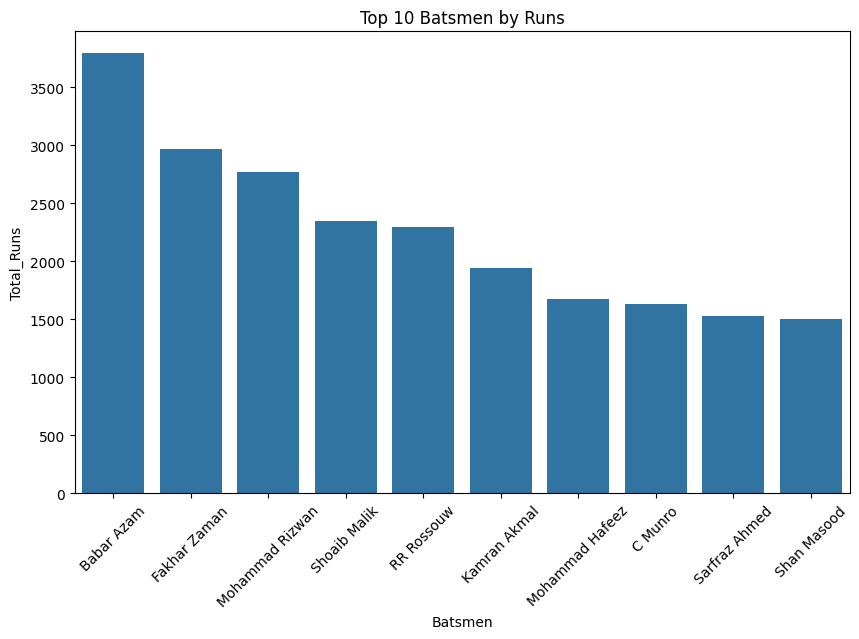

In [12]:
top_batsmen = batting_stats.head(10)

plt.figure(figsize=(10,6))

sns.barplot(x = 'Batsman', y= 'Total_Runs', data=top_batsmen)
plt.title('Top 10 Batsmen by Runs')
plt.xlabel('Batsmen')
plt.ylabel('Total_Runs')
plt.xticks(rotation = 45)
plt.show()

In [13]:
# BOWLING ANALYSIS

bowling_stats = df.groupby('bowler').agg({
    'is_wicket':'sum',
    'total_runs':'sum',
    'ball':'count'
}).reset_index()

bowling_stats.columns = ['Bowler','Wickets','Runs_conceded','Balls_Bowled']

# Overs
bowling_stats['Overs'] = (bowling_stats['Balls_Bowled']/ 6)

# Economy Rate

bowling_stats['Economy'] = (
    bowling_stats['Runs_conceded'] / bowling_stats['Overs']
)

bowling_stats = bowling_stats.sort_values(by='Wickets',ascending=False)

Top_bowlers = bowling_stats.head(10)

Top_bowlers

,Bowler,Wickets,Runs_conceded,Balls_Bowled,Overs,Economy
92,Hasan Ali,138,2900,2141,356.833333,8.127043
230,Shaheen Shah Afridi,131,2563,1973,328.833333,7.794222
257,Wahab Riaz,126,2624,2060,343.333333,7.642718
229,Shadab Khan,109,2571,2017,336.166667,7.647992
79,Faheem Ashraf,102,2329,1627,271.166667,8.588814
149,Mohammad Amir,98,2413,1938,323.000000,7.470588
91,Haris Rauf,86,2452,1611,268.500000,9.132216
100,Imad Wasim,82,2277,1935,322.500000,7.060465
241,Sohail Tanvir,67,1738,1329,221.500000,7.846501
252,Usama Mir,64,1486,1069,178.166667,8.340505


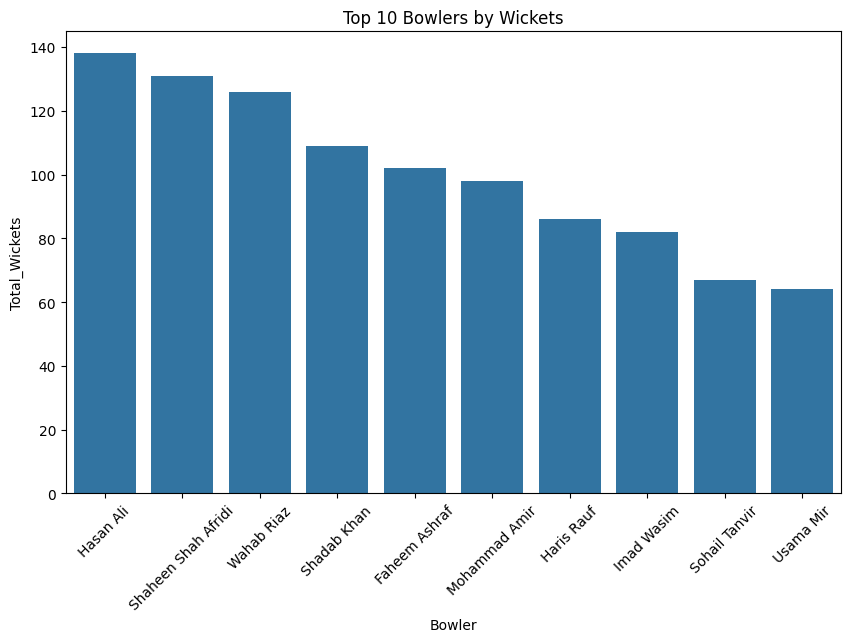

In [14]:

plt.figure(figsize=(10,6))

sns.barplot(x = 'Bowler', y= 'Wickets', data=Top_bowlers)
plt.title('Top 10 Bowlers by Wickets')
plt.xlabel('Bowler')
plt.ylabel('Total_Wickets')
plt.xticks(rotation = 45)
plt.show()

In [15]:
# POWERPLY ANALYSIS
powerplay_stats = df.groupby('batter').agg({
    'batsman_runs':'sum'
}).sort_values(by='batsman_runs',ascending=False)

Top_powerlay_bmen = powerplay_stats.head(10)

Top_powerlay_bmen

,batsman_runs
batter,
Babar Azam,3792
Fakhar Zaman,2969
Mohammad Rizwan,2770
Shoaib Malik,2350
RR Rossouw,2292
Kamran Akmal,1942
Mohammad Hafeez,1672
C Munro,1633
Sarfraz Ahmed,1525


In [16]:
# DEATH OVER ANALYSIS

death_df = df[df['death_over']==1 ] 
death_stats = death_df.groupby('bowler').agg({
    'is_wicket':'sum',
    
}).sort_values(by='is_wicket',ascending=False)

Top_death_bowler = death_stats.head(10)
Top_death_bowler

,is_wicket
bowler,
Shaheen Shah Afridi,71
Wahab Riaz,69
Hasan Ali,57
Mohammad Amir,55
Haris Rauf,49
Faheem Ashraf,45
Sohail Tanvir,39
Mohammad Wasim,34
Mohammad Sami,34


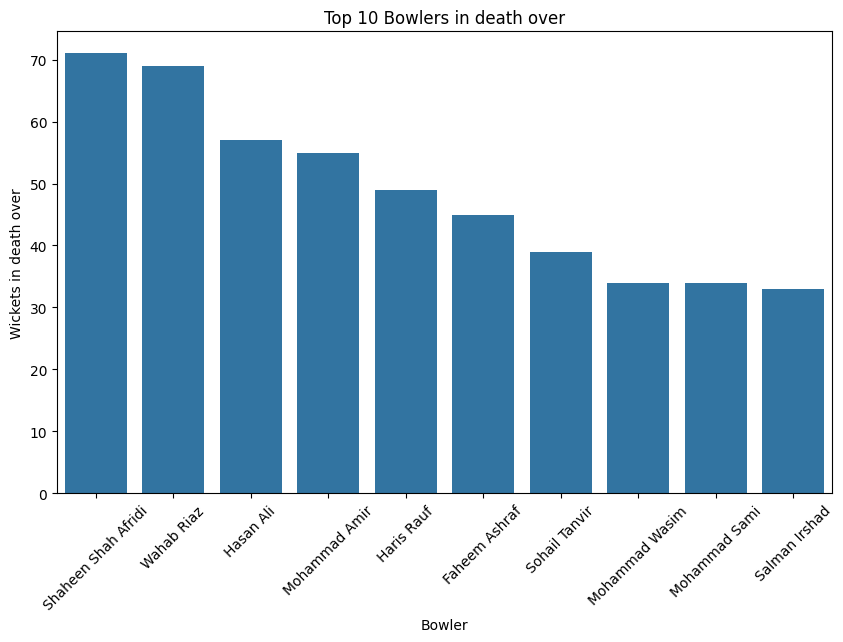

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(x = 'bowler', y= 'is_wicket', data=Top_death_bowler)
plt.title('Top 10 Bowlers in death over')
plt.xlabel('Bowler')
plt.ylabel('Wickets in death over')
plt.xticks(rotation = 45)
plt.show()

In [18]:
# VENUE ANALYSIS 

venue_AVG_runs = df.groupby('venue').agg({
    'total_runs':'mean'
}).sort_values(by='total_runs',ascending=False)

venue_AVG_runs

,total_runs
venue,
Rawalpindi Cricket Stadium,1.559763
"Gaddafi Stadium, Lahore",1.394709
"National Stadium, Karachi",1.393729
National Stadium,1.392809
Gaddafi Stadium,1.380886
Multan Cricket Stadium,1.368919
"Sheikh Zayed Stadium, Abu Dhabi",1.364716
Sharjah Cricket Stadium,1.269152
Dubai International Cricket Stadium,1.236340


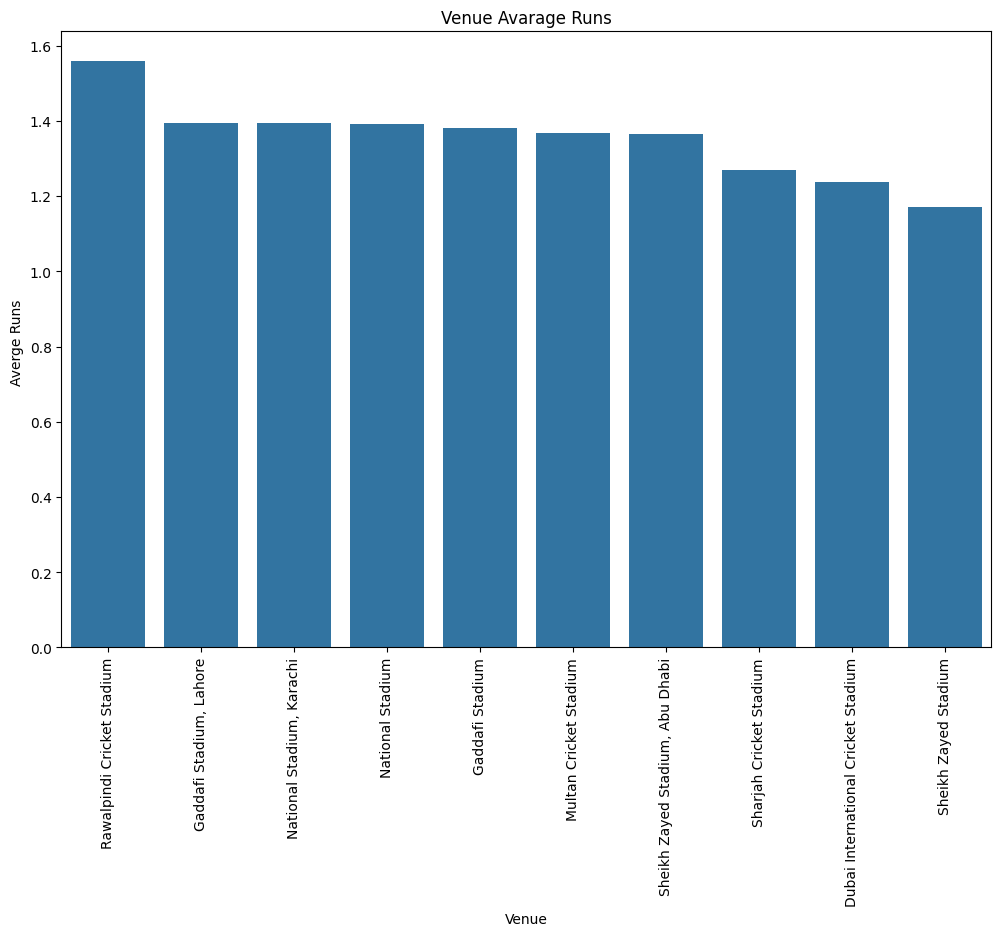

In [19]:
plt.figure(figsize=(12,8))

sns.barplot(x = 'venue', y= 'total_runs', data=venue_AVG_runs)
plt.title('Venue Avarage Runs')
plt.xlabel('Venue')
plt.ylabel('Averge Runs ')
plt.xticks(rotation = 90)
plt.show()

In [20]:
# TEAM ANALYSIS 

best_batting_team = df.groupby('batting_team').agg({
    'total_runs':'sum'
}).sort_values(by='total_runs',ascending=False)

best_batting_team

,total_runs
batting_team,
Peshawar Zalmi,18359
Islamabad United,18014
Lahore Qalandars,17239
Karachi Kings,16247
Quetta Gladiators,16000
Multan Sultans,14554


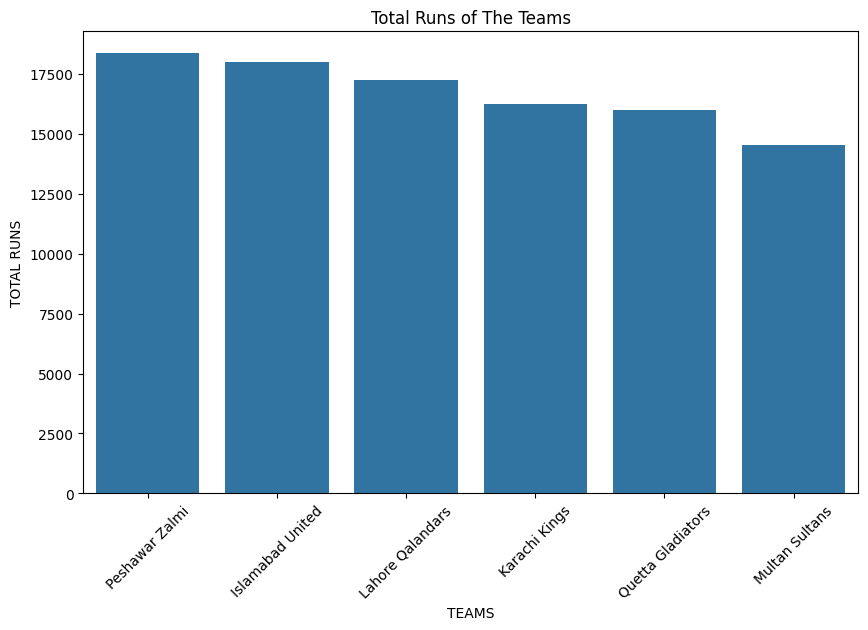

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(x = 'batting_team', y= 'total_runs', data=best_batting_team)
plt.title('Total Runs of The Teams')
plt.xlabel('TEAMS')
plt.ylabel('TOTAL RUNS')
plt.xticks(rotation = 45)
plt.show()

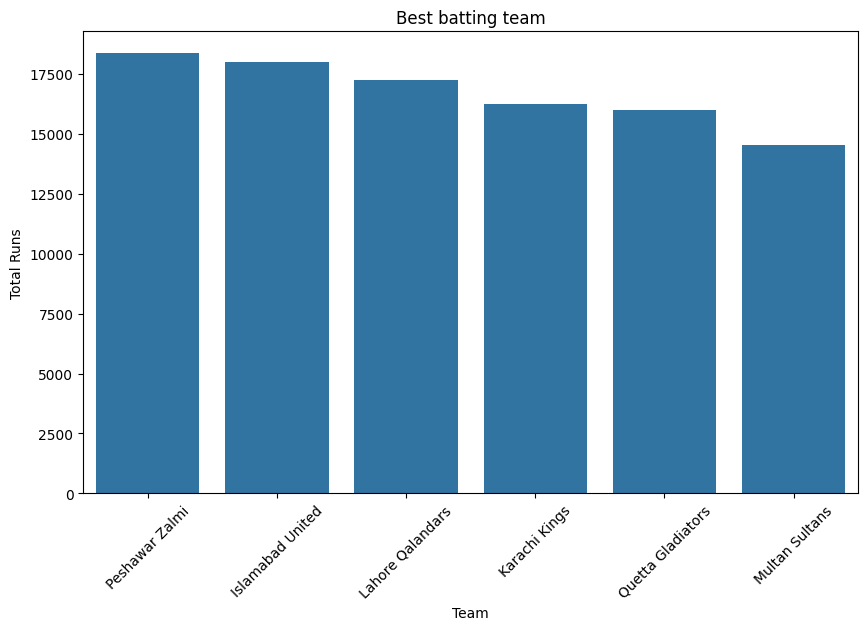

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(x = 'batting_team', y= 'total_runs', data=best_batting_team)
plt.title('Best batting team')
plt.xlabel('Team')
plt.ylabel('Total Runs')
plt.xticks(rotation = 45)
plt.show()

In [23]:
# PLAYER TO PLAYER ANALYSIS 

matchup_stats = []
for batter in top_batsmen['Batsman']:
    for bowler in Top_bowlers['Bowler']:
        temp_df = df[(df['batter'] == batter) & (df['bowler'] == bowler)]
        if len(temp_df) > 0:
            runs = temp_df['batsman_runs'].sum()
            
            
            balls = len(temp_df)
            wickets = temp_df['is_wicket'].sum()

            strike_rate = (runs/ balls) * 100
            
            matchup_stats.append({
                'Batter':batter,
                'Bowler': bowler,
                'Runs': runs,
                "wickets" : wickets,
                'Strike Rate': round(strike_rate, 2), 
                
            })


In [24]:
matchup_df = pd.DataFrame(matchup_stats)

matchup_df = matchup_df.fillna(0)


In [25]:
pivot_table = matchup_df.pivot_table(index='Batter',columns='Bowler',values="Strike Rate",fill_value = 0)
pivot_table


Bowler,Faheem Ashraf,Haris Rauf,Hasan Ali,Imad Wasim,Mohammad Amir,Shadab Khan,Shaheen Shah Afridi,Sohail Tanvir,Usama Mir,Wahab Riaz
Batter,,,,,,,,,,
Babar Azam,155.56,135.09,110.83,126.92,80.00,120.00,130.38,92.59,88.00,154.02
C Munro,200.00,157.69,125.00,93.33,138.46,0.00,100.00,165.22,208.11,54.55
Fakhar Zaman,135.82,0.00,122.54,155.00,84.62,154.00,0.00,104.55,106.06,104.55
Kamran Akmal,157.69,100.00,81.25,189.47,89.83,211.11,100.00,95.79,223.08,0.00
Mohammad Hafeez,177.27,260.00,188.24,81.82,93.55,89.80,33.33,93.33,137.50,150.00
Mohammad Rizwan,139.71,157.65,107.27,123.53,112.00,80.43,113.51,114.29,133.33,135.29
RR Rossouw,169.57,175.86,153.73,115.79,106.67,89.66,142.86,226.67,126.67,123.08
Sarfraz Ahmed,113.51,140.43,110.53,123.53,100.00,122.58,131.71,160.00,80.00,145.76
Shan Masood,143.59,121.95,86.67,127.78,126.67,162.50,100.00,161.76,80.00,103.23


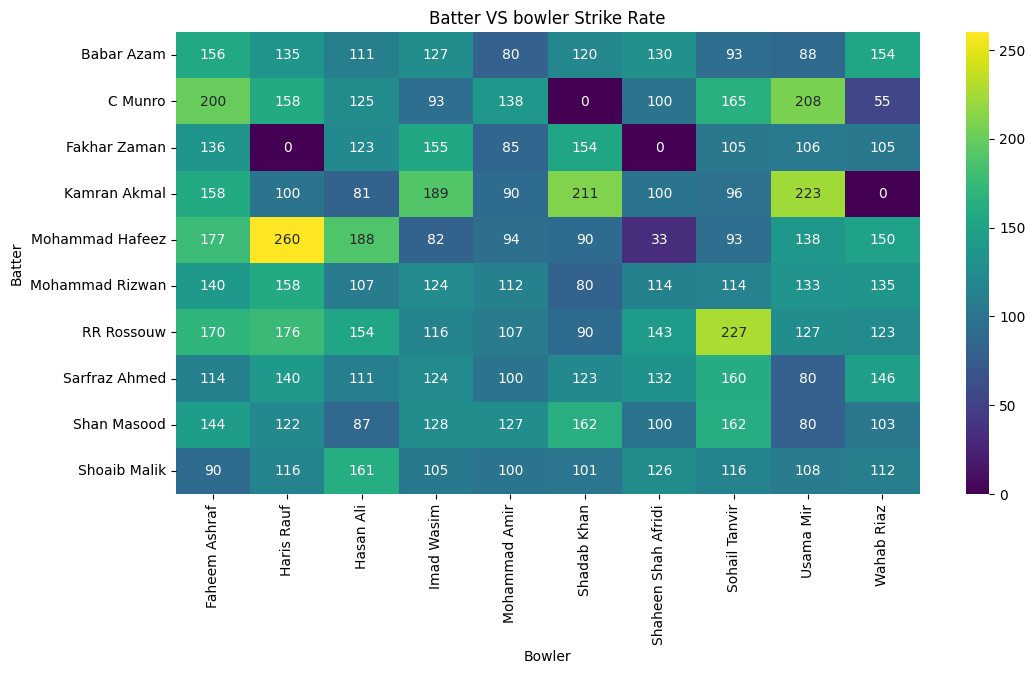

In [26]:
plt.figure(figsize=(12,6))

sns.heatmap(pivot_table, annot=True, fmt= '.0f', cmap= 'viridis')
plt.title('Batter VS bowler Strike Rate')
plt.xlabel('Bowler')
plt.ylabel('Batter')
plt.show()

In [27]:
df.to_csv('Cricket_Data.csv')